# Search Algorithms Lab

This notebook demonstrates heuristic evaluation and Greedy Best-First Search using weighted warehouse and airport graphs. Each task has its own NetworkX visualization.

In [1]:
import math
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

from searchAlgos import (
    airport_graph,
    airport_locations,
    gbfs,
    heuristic,
    verify_heuristic_condition,
    warehouse_graph,
    warehouse_locations,
)

## Task 1: Designing a Heuristic for a Warehouse Robot

The heuristic is the Euclidean distance from a location to the Packing Station.

In [2]:
goal = "Packing_Station"
heuristic_data = [
    {"Location": node, "h(n)": round(heuristic(node, goal, warehouse_locations), 2)}
    for node in warehouse_locations
]
heuristic_df = pd.DataFrame(heuristic_data)
print("Warehouse heuristic values")
display(heuristic_df)

checks_df = pd.DataFrame(
    verify_heuristic_condition(warehouse_graph, warehouse_locations, goal)
).round(2)
print("Heuristic condition: h(n) <= cost(n,m) + h(m)")
display(checks_df)
print(f"Passed checks: {int(checks_df['satisfied'].sum())}/{len(checks_df)}")
print("Euclidean distance is suitable because the coordinates represent physical locations and provide a direct estimate of remaining travel distance.")

Warehouse heuristic values


,Location,h(n)
0,Receiving_Area,9.22
1,Storage_B,6.32
2,Storage_A,7.07
3,Sorting_Area,5.00
4,Inspection_Area,2.24
5,Packing_Station,0.00


Heuristic condition: h(n) <= cost(n,m) + h(m)


,edge,h(n),cost + h(m),satisfied
0,Receiving_Area -> Storage_B,9.22,10.42,True
1,Receiving_Area -> Storage_A,9.22,9.27,True
2,Storage_B -> Inspection_Area,6.32,7.24,True
3,Storage_B -> Sorting_Area,6.32,11.00,True
4,Storage_A -> Sorting_Area,7.07,7.20,True
5,Sorting_Area -> Inspection_Area,5.00,5.44,True
6,Sorting_Area -> Packing_Station,5.00,5.00,True
7,Inspection_Area -> Packing_Station,2.24,2.20,False


Passed checks: 7/8
Euclidean distance is suitable because the coordinates represent physical locations and provide a direct estimate of remaining travel distance.


### Task 1 NetworkX Visualization

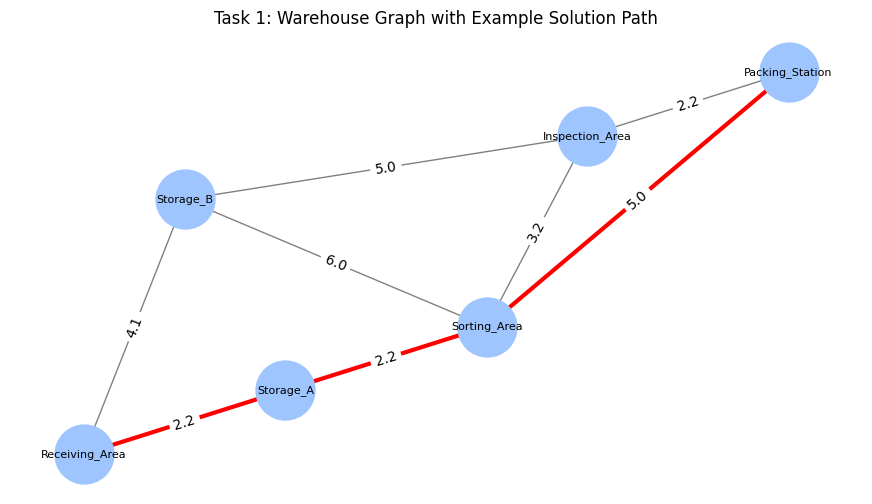

In [3]:
warehouse_network = nx.DiGraph()
warehouse_network.add_nodes_from(warehouse_locations)
for node, neighbors in warehouse_graph.items():
    for neighbor, cost in neighbors.items():
        warehouse_network.add_edge(node, neighbor, weight=cost)

warehouse_path = ["Receiving_Area", "Storage_A", "Sorting_Area", "Packing_Station"]
warehouse_path_edges = set(zip(warehouse_path, warehouse_path[1:]))
warehouse_edge_colors = [
    "red" if edge in warehouse_path_edges else "gray"
    for edge in warehouse_network.edges
]
warehouse_edge_widths = [
    3 if edge in warehouse_path_edges else 1
    for edge in warehouse_network.edges
]

figure, axis = plt.subplots(figsize=(11, 6))
nx.draw_networkx_nodes(warehouse_network, warehouse_locations, node_color="#9ec5fe", node_size=1800, ax=axis)
nx.draw_networkx_labels(warehouse_network, warehouse_locations, font_size=8, ax=axis)
nx.draw_networkx_edges(warehouse_network, warehouse_locations, edge_color=warehouse_edge_colors, width=warehouse_edge_widths, arrows=True, arrowsize=18, ax=axis)
nx.draw_networkx_edge_labels(warehouse_network, warehouse_locations, edge_labels=nx.get_edge_attributes(warehouse_network, "weight"), ax=axis)
axis.set_title("Task 1: Warehouse Graph with Example Solution Path")
axis.set_axis_off()
plt.show()

## Task 2: Greedy Best-First Search for Airport Baggage Handling

GBFS expands the frontier node with the smallest Euclidean heuristic value, using f(n) = h(n).

In [4]:
start = "Baggage_Area"
goal = "Departure_Gate"
path, total_cost, expansion_order = gbfs(start, goal, airport_graph, airport_locations)

print("GBFS Search")
print("Expansion order:")
print(" -> ".join(expansion_order))
print("Solution path:")
print(" -> ".join(path))
print(f"Total path cost: {total_cost:.2f}")
print("GBFS selected this order because it always prioritizes the node with the smallest estimated distance to the Departure Gate.")

GBFS Search
Expansion order:
Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate
Solution path:
Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate
Total path cost: 12.30
GBFS selected this order because it always prioritizes the node with the smallest estimated distance to the Departure Gate.


### Task 2 NetworkX Visualization

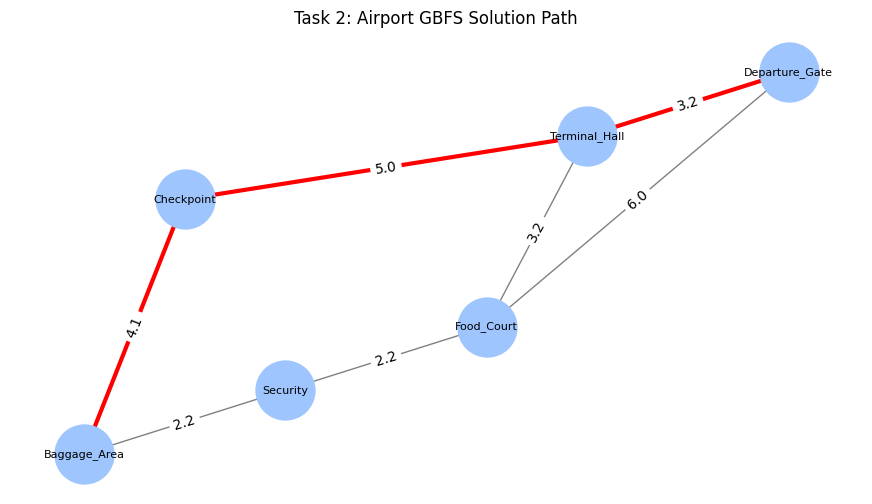

In [5]:
airport_network = nx.DiGraph()
airport_network.add_nodes_from(airport_locations)
for node, neighbors in airport_graph.items():
    for neighbor, cost in neighbors.items():
        airport_network.add_edge(node, neighbor, weight=cost)

airport_path_edges = set(zip(path, path[1:]))
airport_edge_colors = [
    "red" if edge in airport_path_edges else "gray"
    for edge in airport_network.edges
]
airport_edge_widths = [
    3 if edge in airport_path_edges else 1
    for edge in airport_network.edges
]

figure, axis = plt.subplots(figsize=(11, 6))
nx.draw_networkx_nodes(airport_network, airport_locations, node_color="#9ec5fe", node_size=1800, ax=axis)
nx.draw_networkx_labels(airport_network, airport_locations, font_size=8, ax=axis)
nx.draw_networkx_edges(airport_network, airport_locations, edge_color=airport_edge_colors, width=airport_edge_widths, arrows=True, arrowsize=18, ax=axis)
nx.draw_networkx_edge_labels(airport_network, airport_locations, edge_labels=nx.get_edge_attributes(airport_network, "weight"), ax=axis)
axis.set_title("Task 2: Airport GBFS Solution Path")
axis.set_axis_off()
plt.show()